# SKIP - Interview

In [ ]:
# Feel free to use this notebook for any data exploration you feel is useful
import pandas as pd
import numpy as np
from math import radians, sin, cos, sqrt, atan2

import networkx as nx
from IPython.display import Image, display
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Cleaning, exploration, feature engineering

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/final_dataset.csv')

This dataset tracks courier movements and order details for 1 days from Apr 01 - Apr 2

1. courier_id: Unique identifier for each courier.
2. order_number: Unique identifier for each order.
3. courier_location_timestamp: Timestamp of the courier’s location.
4. courier_lat, courier_lon: Latitude and longitude of the courier at the timestamp.
5. order_created_timestamp: When the order was created.
6. restaurant_lat, restaurant_lon: Latitude and longitude of the restaurant.

In [ ]:
# Convert timestamp columns to datetime with ISO8601 format
try:
    df['courier_location_timestamp'] = pd.to_datetime(df['courier_location_timestamp'], format='ISO8601', utc=True)
    df['order_created_timestamp'] = pd.to_datetime(df['order_created_timestamp'], format='ISO8601', utc=True)
except ValueError as e:
    print(f"Error parsing timestamps: {e}")
    # Optional: Inspect problematic rows
    print("Problematic rows (sample):")
    print(df[['courier_location_timestamp', 'order_created_timestamp']].head())
    raise

In [ ]:
print("Total rows: " + str(len(df)))
print("Total unique courier: " + str(len(df.courier_id.unique())))
print("Total unique order: " + str(len(df.order_number.unique())))
print("Total unique restaurant: " + str(len(df.restaurant_lat.unique())))

Total rows: 20577
Total unique courier: 505
Total unique order: 1923
Total unique restaurant: 269


In [ ]:
# courier_location_timestamp & order_created_timestamp -> duration of this dataset is one day

# Get the min and max timestamp of courier_location_timestamp & order_created_timestamp
min_courier_time = df['courier_location_timestamp'].min()
max_courier_time = df['courier_location_timestamp'].max()
min_order_time = df['order_created_timestamp'].min()
max_order_time = df['order_created_timestamp'].max()

print(f"Minimum Courier Location Timestamp: {min_courier_time}")
print(f"Maximum Courier Location Timestamp: {max_courier_time}")
print(f"Minimum Order Created Timestamp: {min_order_time}")
print(f"Maximum Order Created Timestamp: {max_order_time}")

Minimum Courier Location Timestamp: 2021-04-01 06:02:40.687000+00:00
Maximum Courier Location Timestamp: 2021-04-02 06:03:27.098000+00:00
Minimum Order Created Timestamp: 2021-04-01 04:48:40+00:00
Maximum Order Created Timestamp: 2021-04-02 06:02:35+00:00


In [ ]:
# Define the time range
start_time = pd.to_datetime('2021-04-01 06:00:00+00:00', format='ISO8601', utc=True)
end_time = pd.to_datetime('2021-04-02 06:00:00+00:00', format='ISO8601', utc=True)

# Identify order_numbers where ALL courier_location_timestamp and order_created_timestamp are within the range
valid_order_numbers = df.groupby('order_number').filter(
    lambda x: (x['courier_location_timestamp'].between(start_time, end_time)).all() and
              (x['order_created_timestamp'].between(start_time, end_time)).all()
)['order_number'].unique()

# Filter the original dataframe to keep only valid order_numbers
df_filtered = df[df['order_number'].isin(valid_order_numbers)].copy()

print(f"Original DataFrame shape: {df.shape}")
print(f"Filtered DataFrame shape: {df_filtered.shape}")

min_courier_time = df_filtered['courier_location_timestamp'].min()
max_courier_time = df_filtered['courier_location_timestamp'].max()
min_order_time = df_filtered['order_created_timestamp'].min()
max_order_time = df_filtered['order_created_timestamp'].max()

print(f"Minimum Courier Location Timestamp: {min_courier_time}")
print(f"Maximum Courier Location Timestamp: {max_courier_time}")
print(f"Minimum Order Created Timestamp: {min_order_time}")
print(f"Maximum Order Created Timestamp: {max_order_time}")

Original DataFrame shape: (20577, 8)
Filtered DataFrame shape: (17286, 8)
Minimum Courier Location Timestamp: 2021-04-01 06:02:43.366000+00:00
Maximum Courier Location Timestamp: 2021-04-02 05:59:58.145000+00:00
Minimum Order Created Timestamp: 2021-04-01 06:00:08+00:00
Maximum Order Created Timestamp: 2021-04-02 05:58:49+00:00


In [ ]:
# Sort the DataFrame by order_number and then by courier_location_timestamp

df_sorted = df_filtered.sort_values(by=['order_number', 'courier_location_timestamp'])

In [ ]:
# Haversine formula to calculate distance between two lat/lon points, on a sphere (as an approximation of real distance)
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth's radius in km
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    return R * c

In [ ]:
# 1. Calculate distance between courier and restaurant
df_sorted['distance_km'] = df_sorted.apply(
    lambda row: haversine(row['courier_lat'], row['courier_lon'], row['restaurant_lat'], row['restaurant_lon']),
    axis=1
)

# 2. Calculate cost based on distance (20 cents per km)
df_sorted['cost'] = df_sorted['distance_km'] * 0.20

# 3. Extract hour from order_created_timestamp
df_sorted['order_hour'] = df_sorted['order_created_timestamp'].dt.hour
#df_sorted['order_day'] = df_sorted['order_created_timestamp'].dt.day_name()

# 3. Extract hour from courrier_timestamp
df_sorted['courier_hour'] = df_sorted['courier_location_timestamp'].dt.hour


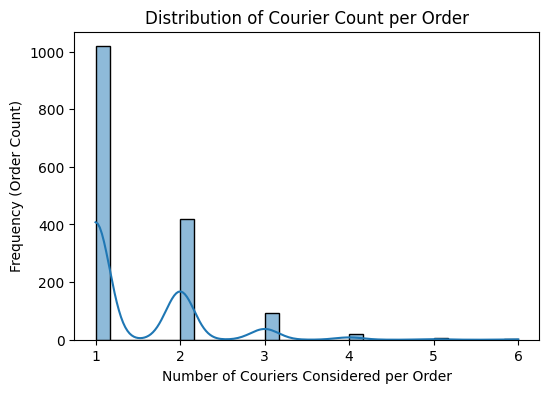

In [ ]:
# % of unsucessufully assigned  order
# Group by order_number and count the number of unique courier_id
counts_unsucessuful_assignment = df_sorted.groupby('order_number')['courier_id'].nunique().reset_index(name='courier_count')

# Plot the distribution of courier counts per order
plt.figure(figsize=(6, 4))
sns.histplot(counts_unsucessuful_assignment['courier_count'], bins=30, kde=True)
plt.title('Distribution of Courier Count per Order')
plt.xlabel('Number of Couriers Considered per Order')
plt.ylabel('Frequency (Order Count)')
plt.show()

In [ ]:
# create df_sorted["number_of_unsucessful_assignment"] -> number of couriers per order - 1
df_sorted["number_of_unsucessful_assignment"] = df_sorted.groupby("order_number")["courier_id"].transform("nunique") - 1

In [ ]:
# Group by order_number and courier_id, then assign a label to each unique courier within the order
df_sorted['courier_order_rank'] = df_sorted.groupby('order_number')['courier_id'].rank(method='dense', ascending=True) - 1
df_sorted.head()

,courier_id,order_number,courier_location_timestamp,courier_lat,courier_lon,order_created_timestamp,restaurant_lat,restaurant_lon,distance_km,cost,order_hour,courier_hour,number_of_unsucessful_assignment,courier_order_rank
6582,67278c93hoho1c7ehoho41a7hohobb9bhohoae8ad6736840,280946408,2021-04-01 06:06:44.100000+00:00,50.497626,-104.642409,2021-04-01 06:00:08+00:00,50.496454,-104.638492,0.306192,0.061238,6,6,0,0.0
780,67278c93hoho1c7ehoho41a7hohobb9bhohoae8ad6736840,280946408,2021-04-01 06:07:52.259000+00:00,50.497625,-104.642408,2021-04-01 06:00:08+00:00,50.496454,-104.638492,0.306127,0.061225,6,6,0,0.0
7270,67278c93hoho1c7ehoho41a7hohobb9bhohoae8ad6736840,280946408,2021-04-01 06:08:53.133000+00:00,50.497626,-104.642405,2021-04-01 06:00:08+00:00,50.496454,-104.638492,0.305952,0.061190,6,6,0,0.0
5173,67278c93hoho1c7ehoho41a7hohobb9bhohoae8ad6736840,280946408,2021-04-01 06:10:03.150000+00:00,50.497704,-104.641449,2021-04-01 06:00:08+00:00,50.496454,-104.638492,0.251129,0.050226,6,6,0,0.0
3490,67278c93hoho1c7ehoho41a7hohobb9bhohoae8ad6736840,280946408,2021-04-01 06:11:14.132000+00:00,50.496540,-104.640569,2021-04-01 06:00:08+00:00,50.496454,-104.638492,0.147288,0.029458,6,6,0,0.0


In [ ]:
# Identify the last unique courier_id for each order
last_couriers = df_sorted.groupby('order_number')['courier_id'].transform('last')

# Create the binary column: 0 if it's the last courier, 1 otherwise
df_sorted['order_assignment_unsuccess_binary'] = (df_sorted['courier_id'] != last_couriers).astype(int)

display(df_sorted.head())

,courier_id,order_number,courier_location_timestamp,courier_lat,courier_lon,order_created_timestamp,restaurant_lat,restaurant_lon,distance_km,cost,order_hour,courier_hour,number_of_unsucessful_assignment,courier_order_rank,order_assignment_unsuccess_binary
6582,67278c93hoho1c7ehoho41a7hohobb9bhohoae8ad6736840,280946408,2021-04-01 06:06:44.100000+00:00,50.497626,-104.642409,2021-04-01 06:00:08+00:00,50.496454,-104.638492,0.306192,0.061238,6,6,0,0.0,0
780,67278c93hoho1c7ehoho41a7hohobb9bhohoae8ad6736840,280946408,2021-04-01 06:07:52.259000+00:00,50.497625,-104.642408,2021-04-01 06:00:08+00:00,50.496454,-104.638492,0.306127,0.061225,6,6,0,0.0,0
7270,67278c93hoho1c7ehoho41a7hohobb9bhohoae8ad6736840,280946408,2021-04-01 06:08:53.133000+00:00,50.497626,-104.642405,2021-04-01 06:00:08+00:00,50.496454,-104.638492,0.305952,0.061190,6,6,0,0.0,0
5173,67278c93hoho1c7ehoho41a7hohobb9bhohoae8ad6736840,280946408,2021-04-01 06:10:03.150000+00:00,50.497704,-104.641449,2021-04-01 06:00:08+00:00,50.496454,-104.638492,0.251129,0.050226,6,6,0,0.0,0
3490,67278c93hoho1c7ehoho41a7hohobb9bhohoae8ad6736840,280946408,2021-04-01 06:11:14.132000+00:00,50.496540,-104.640569,2021-04-01 06:00:08+00:00,50.496454,-104.638492,0.147288,0.029458,6,6,0,0.0,0


In [ ]:
#df_sorted[df_sorted["order_number"] == 280946846]

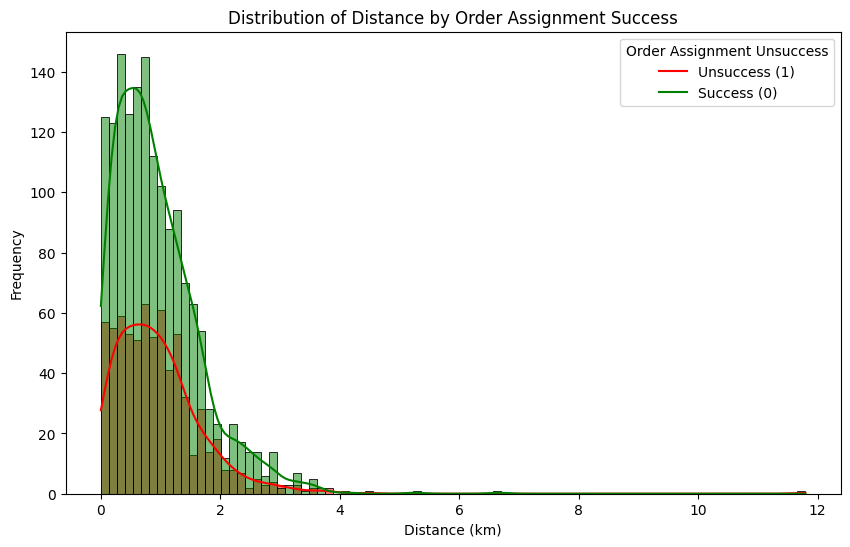

In [ ]:
# cause of order_assignment_unsuccess_binary?
# distance, rush hour
# Create df_sorted_first by dropping duplicates based on order_number and courier_id, keeping the first entry
df_sorted_first = df_sorted.drop_duplicates(subset=['order_number', 'courier_id'], keep='first').copy()

plt.figure(figsize=(10, 6))
sns.histplot(data=df_sorted_first, x='distance_km', hue='order_assignment_unsuccess_binary', kde=True, palette={1: 'red', 0: 'green'})
plt.title('Distribution of Distance by Order Assignment Success')
plt.xlabel('Distance (km)')
plt.ylabel('Frequency')
plt.legend(title='Order Assignment Unsuccess', labels=['Unsuccess (1)', 'Success (0)'])
plt.show()

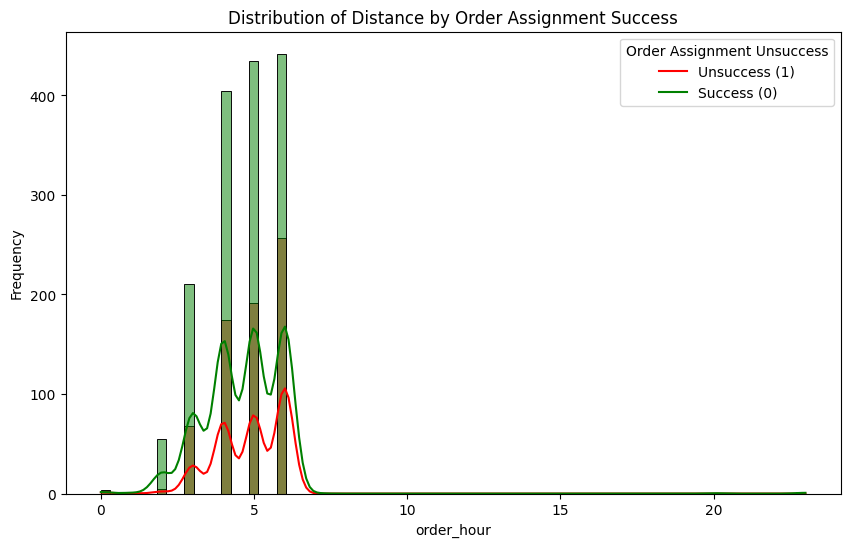

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_sorted_first, x='order_hour', hue='order_assignment_unsuccess_binary', kde=True, palette={1: 'red', 0: 'green'})
plt.title('Distribution of Distance by Order Assignment Success')
plt.xlabel('order_hour')
plt.ylabel('Frequency')
plt.legend(title='Order Assignment Unsuccess', labels=['Unsuccess (1)', 'Success (0)'])
plt.show()

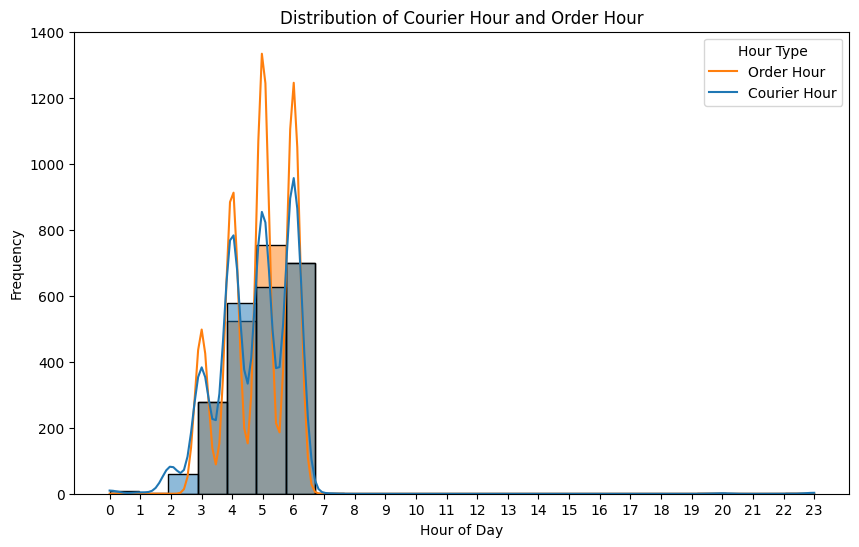

In [ ]:
# Reshape data for plotting

df_sorted_first_success = df_sorted.drop_duplicates(subset=['order_number'], keep='first')
df_hours = df_sorted_first[['order_hour', 'courier_hour']].melt(var_name='hour_type', value_name='hour')

# Plot overlapping distributions
plt.figure(figsize=(10, 6))
sns.histplot(data=df_hours, x='hour', hue='hour_type', bins=24, kde=True, common_norm=False)
plt.title('Distribution of Courier Hour and Order Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Frequency')
plt.xticks(range(0, 24))
plt.legend(title='Hour Type', labels=['Order Hour', 'Courier Hour'])
plt.show()

In [ ]:
# Group by order_number and perform aggregations
order_summary = df_sorted.groupby('order_number').agg(
    courier_count=('courier_id', 'count'),
    total_distance_km=('distance_km', 'sum'),
    total_cost=('cost', 'sum'),
    timestamp_order_created=('order_created_timestamp', 'first'), #order created time
    timestamp_to_accept_order=('courier_location_timestamp', 'first'), #courier accept order on app
    timestamp_to_get_order=('courier_location_timestamp', 'last'), #courier get order from resto
    first_order_hour=('order_hour', 'first'),
    last_order_hour=('order_hour', 'last'),
    first_courier_lat=('courier_lat', 'first'),
    first_courier_lon=('courier_lon', 'first'),
    first_restaurant_lat=('restaurant_lat', 'first'),
    first_restaurant_lon=('restaurant_lon', 'first')
).reset_index()

# time_to_restaurant_minutes
order_summary['time_to_accept_order'] = order_summary['timestamp_to_accept_order'] - order_summary['timestamp_order_created']
order_summary['time_to_accept_order'] = order_summary['time_to_accept_order'].dt.total_seconds() / 60

order_summary['time_to_restaurant_minutes'] = order_summary['timestamp_to_get_order'] - order_summary['timestamp_to_accept_order']
order_summary['time_to_restaurant_minutes'] = order_summary['time_to_restaurant_minutes'].dt.total_seconds() / 60

order_summary['tot_time_to_get_order'] = order_summary['time_to_accept_order'] + order_summary['time_to_restaurant_minutes']
display(order_summary.head())

,order_number,courier_count,total_distance_km,total_cost,timestamp_order_created,timestamp_to_accept_order,timestamp_to_get_order,first_order_hour,last_order_hour,first_courier_lat,first_courier_lon,first_restaurant_lat,first_restaurant_lon,time_to_accept_order,time_to_restaurant_minutes,tot_time_to_get_order
0,280946408,6,1.338274,0.267655,2021-04-01 06:00:08+00:00,2021-04-01 06:06:44.100000+00:00,2021-04-01 06:12:17.288000+00:00,6,6,50.497626,-104.642409,50.496454,-104.638492,6.601667,5.553133,12.154800
1,280946435,7,3.172800,0.634560,2021-04-01 06:00:10+00:00,2021-04-01 06:10:02.325000+00:00,2021-04-01 06:16:34.234000+00:00,6,6,50.433371,-104.541239,50.444124,-104.545164,9.872083,6.531817,16.403900
2,280946558,16,33.418159,6.683632,2021-04-01 06:00:22+00:00,2021-04-01 06:20:19.151000+00:00,2021-04-01 06:35:28.194000+00:00,6,6,50.433388,-104.631226,50.444714,-104.617788,19.952517,15.150717,35.103233
3,280946645,8,4.462893,0.892579,2021-04-01 06:00:31+00:00,2021-04-01 06:10:11.270000+00:00,2021-04-01 06:17:16.267000+00:00,6,6,50.447129,-104.600948,50.449888,-104.606199,9.671167,7.083283,16.754450
4,280946646,31,7.341009,1.468202,2021-04-01 06:00:32+00:00,2021-04-01 06:09:58.245000+00:00,2021-04-01 06:40:18.293000+00:00,6,6,50.406716,-104.656555,50.406109,-104.652070,9.437417,30.334133,39.771550


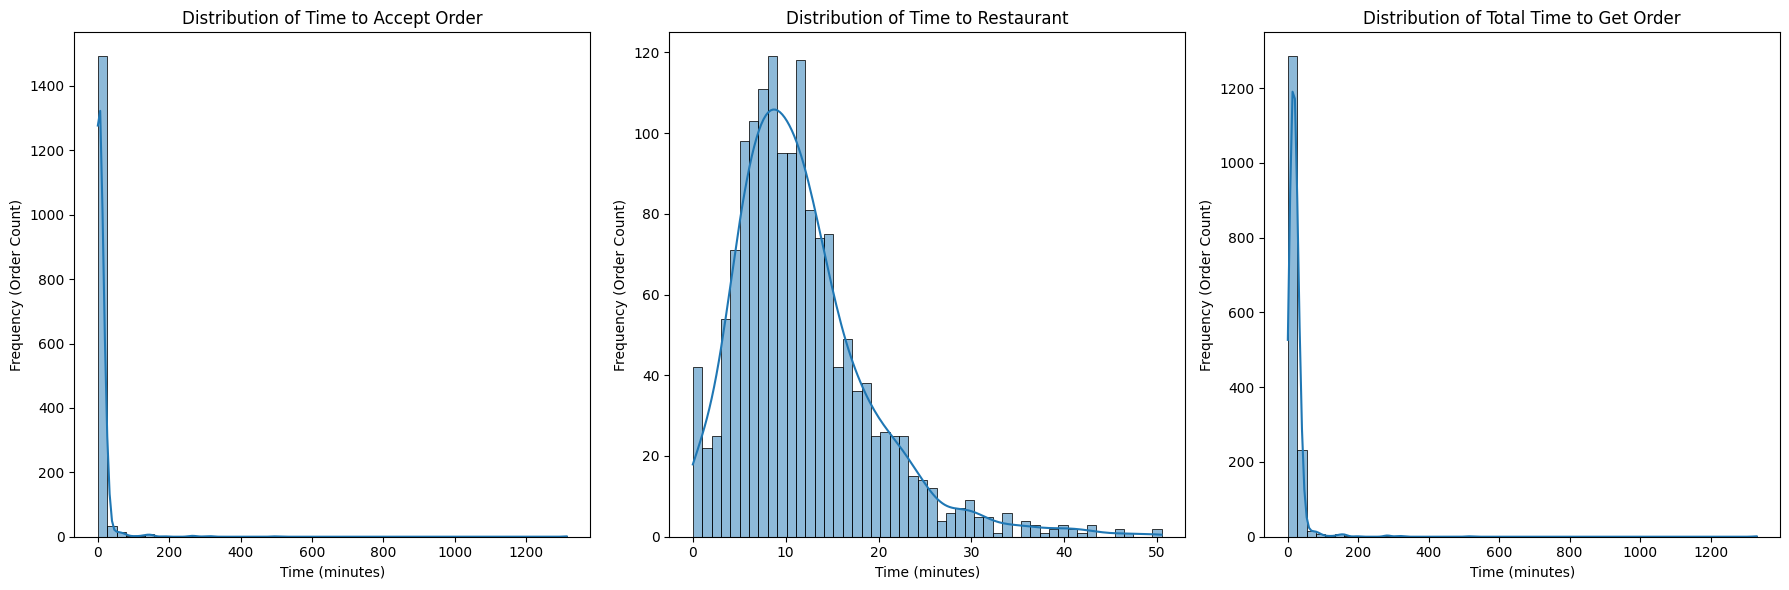

In [ ]:
# plot
# 1. time_to_accept_order from order creation
# 2. tot_time_to_get_order from order creation
# 3. time_to_restaurant_minutes from time_to_accept_order

# Plot distributions of time metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.histplot(order_summary['time_to_accept_order'], ax=axes[0], kde=True, bins=50)
axes[0].set_title('Distribution of Time to Accept Order')
axes[0].set_xlabel('Time (minutes)')
axes[0].set_ylabel('Frequency (Order Count)')

sns.histplot(order_summary['time_to_restaurant_minutes'], ax=axes[1], kde=True, bins=50)
axes[1].set_title('Distribution of Time to Restaurant')
axes[1].set_xlabel('Time (minutes)')
axes[1].set_ylabel('Frequency (Order Count)')

sns.histplot(order_summary['tot_time_to_get_order'], ax=axes[2], kde=True, bins=50)
axes[2].set_title('Distribution of Total Time to Get Order')
axes[2].set_xlabel('Time (minutes)')
axes[2].set_ylabel('Frequency (Order Count)')



plt.tight_layout()
plt.show()


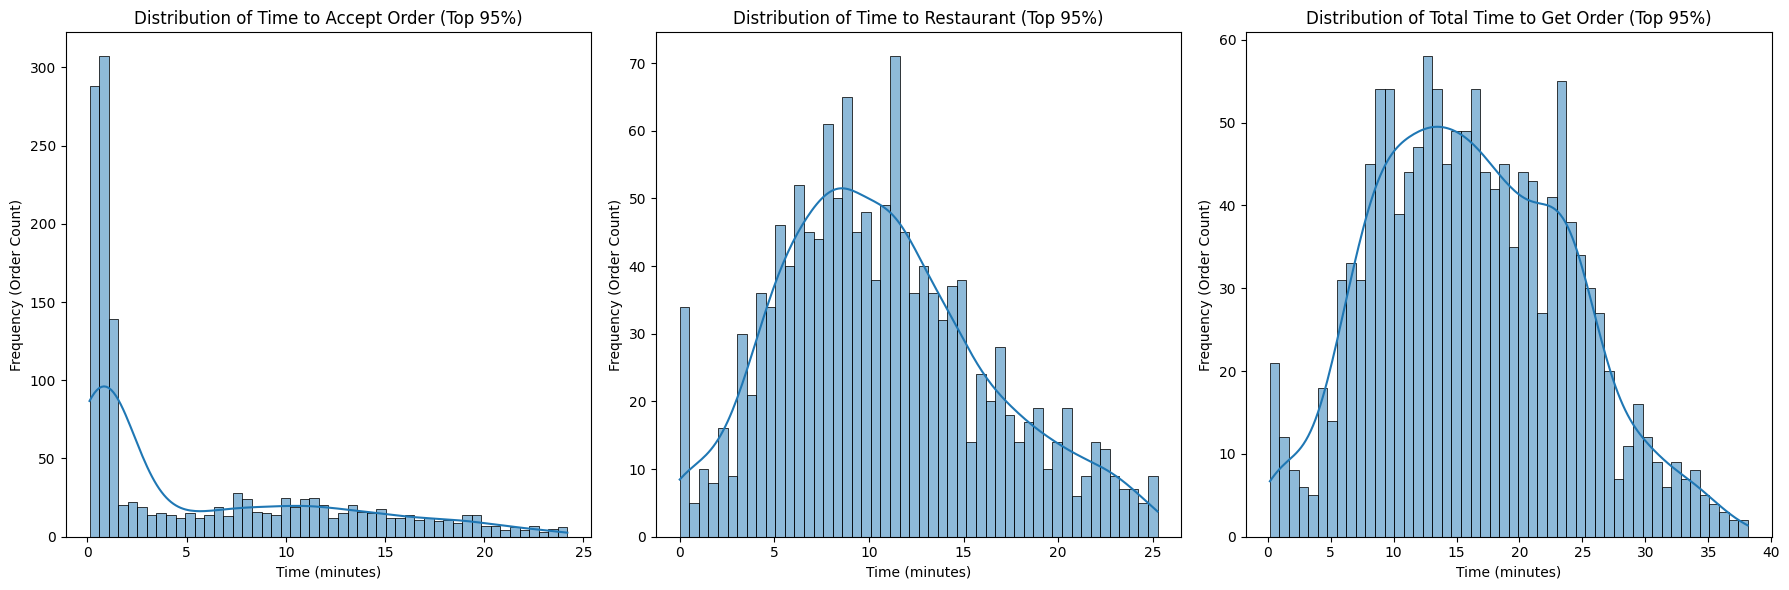

In [ ]:
# Remove outliers (top 5%) for each time metric
time_to_accept_order_threshold = order_summary['time_to_accept_order'].quantile(0.95)
tot_time_to_get_order_threshold = order_summary['tot_time_to_get_order'].quantile(0.95)
time_to_restaurant_minutes_threshold = order_summary['time_to_restaurant_minutes'].quantile(0.95)

order_summary_filtered = order_summary[
    (order_summary['time_to_accept_order'] <= time_to_accept_order_threshold) &
    (order_summary['tot_time_to_get_order'] <= tot_time_to_get_order_threshold) &
    (order_summary['time_to_restaurant_minutes'] <= time_to_restaurant_minutes_threshold)
].copy()

# Plot distributions of time metrics with outliers removed
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.histplot(order_summary_filtered['time_to_accept_order'], ax=axes[0], kde=True, bins=50)
axes[0].set_title('Distribution of Time to Accept Order (Top 95%)')
axes[0].set_xlabel('Time (minutes)')
axes[0].set_ylabel('Frequency (Order Count)')

sns.histplot(order_summary_filtered['time_to_restaurant_minutes'], ax=axes[1], kde=True, bins=50)
axes[1].set_title('Distribution of Time to Restaurant (Top 95%)')
axes[1].set_xlabel('Time (minutes)')
axes[1].set_ylabel('Frequency (Order Count)')

sns.histplot(order_summary_filtered['tot_time_to_get_order'], ax=axes[2], kde=True, bins=50)
axes[2].set_title('Distribution of Total Time to Get Order (Top 95%)')
axes[2].set_xlabel('Time (minutes)')
axes[2].set_ylabel('Frequency (Order Count)')


plt.tight_layout()
plt.show()

In [ ]:
# Identify the outliers

# long time to get order can be caused by either
  # 1. cannot find a courier to accept the order -> shortage of courier/not enough supply of courier vs demand
  # 2. time to get order from courier to restaurant is too long -> assignment of courier is too far
time_to_accept_order_threshold = order_summary['time_to_accept_order'].quantile(0.95)
tot_time_to_get_order_threshold = order_summary['tot_time_to_get_order'].quantile(0.95)
time_to_restaurant_minutes_threshold = order_summary['time_to_restaurant_minutes'].quantile(0.95)

outliers = order_summary[
    (order_summary['time_to_accept_order'] > time_to_accept_order_threshold) |
    (order_summary['tot_time_to_get_order'] > tot_time_to_get_order_threshold) |
    (order_summary['time_to_restaurant_minutes'] > time_to_restaurant_minutes_threshold)
]

print("Order numbers of outliers:")
len(outliers)/len(order_summary) #10%

Order numbers of outliers:


0.10276172125883108

In [ ]:
# Problem: find the most profitable way to deliver these orders

# focus tot_time_to_get_order -> orde to courier assignment problem -> how to assign order to courier -> MIN distance travel

time_to_restaurant_minutes_threshold = order_summary['tot_time_to_get_order'].quantile(0.90)
print(time_to_restaurant_minutes_threshold) # investigate when time to get order is more than ~35min

focused_order = order_summary[(order_summary['tot_time_to_get_order'] > time_to_restaurant_minutes_threshold)]
focused_order

31.961630000000003


,order_number,courier_count,total_distance_km,total_cost,timestamp_order_created,timestamp_to_accept_order,timestamp_to_get_order,first_order_hour,last_order_hour,first_courier_lat,first_courier_lon,first_restaurant_lat,first_restaurant_lon,time_to_accept_order,time_to_restaurant_minutes,tot_time_to_get_order
2,280946558,16,33.418159,6.683632,2021-04-01 06:00:22+00:00,2021-04-01 06:20:19.151000+00:00,2021-04-01 06:35:28.194000+00:00,6,6,50.433388,-104.631226,50.444714,-104.617788,19.952517,15.150717,35.103233
4,280946646,31,7.341009,1.468202,2021-04-01 06:00:32+00:00,2021-04-01 06:09:58.245000+00:00,2021-04-01 06:40:18.293000+00:00,6,6,50.406716,-104.656555,50.406109,-104.652070,9.437417,30.334133,39.771550
7,280946846,11,1.784008,0.356802,2021-04-01 06:00:51+00:00,2021-04-01 06:14:46.850000+00:00,2021-04-01 06:39:45.017000+00:00,6,6,50.408516,-104.661030,50.414444,-104.660051,13.930833,24.969450,38.900283
20,280947673,25,14.583271,2.916654,2021-04-01 06:02:12+00:00,2021-04-01 06:13:18.236000+00:00,2021-04-01 06:37:36.273000+00:00,6,6,50.403931,-104.641374,50.407392,-104.649987,11.103933,24.300617,35.404550
37,280948729,11,3.007648,0.601530,2021-04-01 06:03:53+00:00,2021-04-01 06:30:03.194000+00:00,2021-04-01 06:42:50.273000+00:00,6,6,50.442355,-104.611255,50.444284,-104.605795,26.169900,12.784650,38.954550
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1365,281335999,5,2.522658,0.504532,2021-04-02 05:22:49+00:00,2021-04-02 05:41:15.254000+00:00,2021-04-02 05:58:36.535000+00:00,5,5,50.486492,-104.654546,50.495598,-104.644883,18.437567,17.354683,35.792250
1380,281337124,21,38.905457,7.781091,2021-04-02 05:24:13+00:00,2021-04-02 05:36:18.294000+00:00,2021-04-02 05:56:29.293000+00:00,5,5,50.455221,-104.554470,50.444383,-104.544183,12.088233,20.183317,32.271550
1395,281338111,18,18.793298,3.758660,2021-04-02 05:25:31+00:00,2021-04-02 05:40:56.233000+00:00,2021-04-02 05:58:06.186000+00:00,5,5,50.496704,-104.625660,50.496378,-104.640372,15.420550,17.165883,32.586433
1400,281338453,24,9.953826,1.990765,2021-04-02 05:26:01+00:00,2021-04-02 05:34:33.079000+00:00,2021-04-02 05:58:03.185000+00:00,5,5,50.495930,-104.660298,50.496224,-104.659913,8.534650,23.501767,32.036417


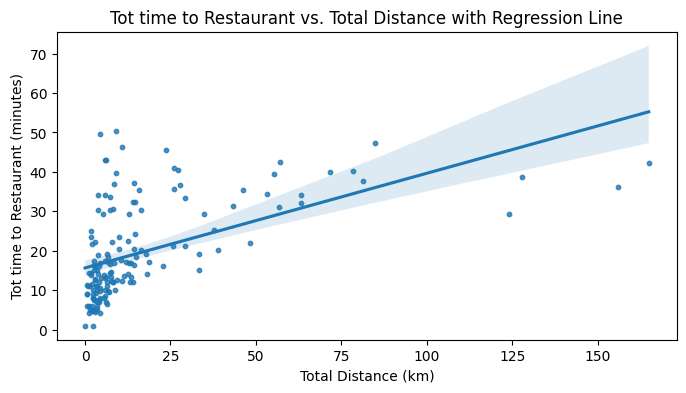


Correlation coefficient between Time to Restaurant and Total Distance: 0.54


In [ ]:
# Investigate correlation between time_to_restaurant_minutes vs total_distance_km
plt.figure(figsize=(8, 4))
# Use regplot to add a regression line
sns.regplot(data=focused_order, x='total_distance_km', y='time_to_restaurant_minutes', scatter_kws={'s': 10})
plt.title('Tot time to Restaurant vs. Total Distance with Regression Line')
plt.xlabel('Total Distance (km)')
plt.ylabel('Tot time to Restaurant (minutes)')
plt.show()

# Calculate and print the correlation coefficient
correlation = focused_order['time_to_restaurant_minutes'].corr(focused_order['total_distance_km'])
print(f"\nCorrelation coefficient between Time to Restaurant and Total Distance: {correlation:.2f}")

In [ ]:
order_summary.head()

,order_number,courier_count,total_distance_km,total_cost,timestamp_order_created,timestamp_to_accept_order,timestamp_to_get_order,first_order_hour,last_order_hour,first_courier_lat,first_courier_lon,first_restaurant_lat,first_restaurant_lon,time_to_accept_order,time_to_restaurant_minutes,tot_time_to_get_order
0,280946408,6,1.338274,0.267655,2021-04-01 06:00:08+00:00,2021-04-01 06:06:44.100000+00:00,2021-04-01 06:12:17.288000+00:00,6,6,50.497626,-104.642409,50.496454,-104.638492,6.601667,5.553133,12.154800
1,280946435,7,3.172800,0.634560,2021-04-01 06:00:10+00:00,2021-04-01 06:10:02.325000+00:00,2021-04-01 06:16:34.234000+00:00,6,6,50.433371,-104.541239,50.444124,-104.545164,9.872083,6.531817,16.403900
2,280946558,16,33.418159,6.683632,2021-04-01 06:00:22+00:00,2021-04-01 06:20:19.151000+00:00,2021-04-01 06:35:28.194000+00:00,6,6,50.433388,-104.631226,50.444714,-104.617788,19.952517,15.150717,35.103233
3,280946645,8,4.462893,0.892579,2021-04-01 06:00:31+00:00,2021-04-01 06:10:11.270000+00:00,2021-04-01 06:17:16.267000+00:00,6,6,50.447129,-104.600948,50.449888,-104.606199,9.671167,7.083283,16.754450
4,280946646,31,7.341009,1.468202,2021-04-01 06:00:32+00:00,2021-04-01 06:09:58.245000+00:00,2021-04-01 06:40:18.293000+00:00,6,6,50.406716,-104.656555,50.406109,-104.652070,9.437417,30.334133,39.771550


In [ ]:
# Profitability: cost is 20 cents per km, distances and time difference

df_sorted.head()

,courier_id,order_number,courier_location_timestamp,courier_lat,courier_lon,order_created_timestamp,restaurant_lat,restaurant_lon,distance_km,cost,order_hour,courier_hour,number_of_unsucessful_assignment,courier_order_rank,order_assignment_unsuccess_binary
6582,67278c93hoho1c7ehoho41a7hohobb9bhohoae8ad6736840,280946408,2021-04-01 06:06:44.100000+00:00,50.497626,-104.642409,2021-04-01 06:00:08+00:00,50.496454,-104.638492,0.306192,0.061238,6,6,0,0.0,0
780,67278c93hoho1c7ehoho41a7hohobb9bhohoae8ad6736840,280946408,2021-04-01 06:07:52.259000+00:00,50.497625,-104.642408,2021-04-01 06:00:08+00:00,50.496454,-104.638492,0.306127,0.061225,6,6,0,0.0,0
7270,67278c93hoho1c7ehoho41a7hohobb9bhohoae8ad6736840,280946408,2021-04-01 06:08:53.133000+00:00,50.497626,-104.642405,2021-04-01 06:00:08+00:00,50.496454,-104.638492,0.305952,0.061190,6,6,0,0.0,0
5173,67278c93hoho1c7ehoho41a7hohobb9bhohoae8ad6736840,280946408,2021-04-01 06:10:03.150000+00:00,50.497704,-104.641449,2021-04-01 06:00:08+00:00,50.496454,-104.638492,0.251129,0.050226,6,6,0,0.0,0
3490,67278c93hoho1c7ehoho41a7hohobb9bhohoae8ad6736840,280946408,2021-04-01 06:11:14.132000+00:00,50.496540,-104.640569,2021-04-01 06:00:08+00:00,50.496454,-104.638492,0.147288,0.029458,6,6,0,0.0,0


In [ ]:
df_sorted.head()

,courier_id,order_number,courier_location_timestamp,courier_lat,courier_lon,order_created_timestamp,restaurant_lat,restaurant_lon,distance_km,cost,order_hour,courier_hour,number_of_unsucessful_assignment,courier_order_rank,order_assignment_unsuccess_binary
6582,67278c93hoho1c7ehoho41a7hohobb9bhohoae8ad6736840,280946408,2021-04-01 06:06:44.100000+00:00,50.497626,-104.642409,2021-04-01 06:00:08+00:00,50.496454,-104.638492,0.306192,0.061238,6,6,0,0.0,0
780,67278c93hoho1c7ehoho41a7hohobb9bhohoae8ad6736840,280946408,2021-04-01 06:07:52.259000+00:00,50.497625,-104.642408,2021-04-01 06:00:08+00:00,50.496454,-104.638492,0.306127,0.061225,6,6,0,0.0,0
7270,67278c93hoho1c7ehoho41a7hohobb9bhohoae8ad6736840,280946408,2021-04-01 06:08:53.133000+00:00,50.497626,-104.642405,2021-04-01 06:00:08+00:00,50.496454,-104.638492,0.305952,0.061190,6,6,0,0.0,0
5173,67278c93hoho1c7ehoho41a7hohobb9bhohoae8ad6736840,280946408,2021-04-01 06:10:03.150000+00:00,50.497704,-104.641449,2021-04-01 06:00:08+00:00,50.496454,-104.638492,0.251129,0.050226,6,6,0,0.0,0
3490,67278c93hoho1c7ehoho41a7hohobb9bhohoae8ad6736840,280946408,2021-04-01 06:11:14.132000+00:00,50.496540,-104.640569,2021-04-01 06:00:08+00:00,50.496454,-104.638492,0.147288,0.029458,6,6,0,0.0,0


In [ ]:
# Group by order_number and courier_id, and calculate the difference between the last and first cost
actual_costs = df_sorted.groupby(['order_number', 'courier_id']).agg(
    first_cost=('cost', 'first'),
    last_cost=('cost', 'last')
).reset_index()

actual_costs['actual_cost'] = actual_costs['first_cost'] - actual_costs['last_cost']

# Sum the actual costs to get the total actual cost
total_actual_cost = actual_costs['actual_cost'].sum()

print(f"Total Actual Cost: ${total_actual_cost:.2f}")
display(actual_costs.head())

Total Actual Cost: $259.72


,order_number,courier_id,first_cost,last_cost,actual_cost
0,280946408,67278c93hoho1c7ehoho41a7hohobb9bhohoae8ad6736840,0.061238,0.004317,0.056921
1,280946435,e125dd35hoho254fhoho42c6hoho9060hoho546964984370,0.245512,0.001368,0.244144
2,280946558,adbb9536hoho0f29hoho4b8chohobb16hoho2da5ec571e5e,0.315697,0.000918,0.314779
3,280946645,1ea4602bhohoed79hoho4b74hohoa512hoho5d1087b5449c,0.096409,0.002430,0.093979
4,280946646,a03c5da9hohod282hoho4daahohob881hoho653cd946c352,0.064993,0.003787,0.061206


In [ ]:
len(actual_costs)

2256

In [ ]:
# Calculate the total number of unsuccessful assignments
# We can use df_first which contains one row per unique order-courier assignment
total_unsuccessful_assignments = df_first[df_first['order_assignment_unsuccess_binary'] == 1].shape[0]

print(f"Total number of unsuccessful assignments: {total_unsuccessful_assignments}")

Total number of unsuccessful assignments: 699


In [ ]:
# Calculate the total time used from courier to restaurant including unsuccessful assignments
# We need to sum the time_to_restaurant_minutes for all entries in df_sorted
# First, ensure time_to_restaurant_minutes is calculated for each row in df_sorted
# Assuming time_to_restaurant_minutes can be approximated by the time difference between consecutive courier locations for an order
# This is not a perfect measure, as it includes travel time between pings, not just to the restaurant.

# A better approach is to use the time difference between the first courier location for an order and the last courier location for that order (which we assumed is when the courier got the order from the restaurant)
# This was calculated in order_summary as 'time_to_restaurant_minutes'

# Let's calculate the total time to get to the restaurant across all orders from order_summary
total_time_to_restaurant_all_orders = order_summary['time_to_restaurant_minutes'].sum()

print(f"Total time spent for couriers to get to restaurants across all orders (minutes): {total_time_to_restaurant_all_orders:.2f}")

Total time spent for couriers to get to restaurants across all orders (minutes): 18346.86


## 2. Modeling

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from geopy.distance import geodesic
import random

In [ ]:
# Problem statement: balance supply/demand in each area, min distance travel & order waiting time to save cost + customer satisfaction

In [ ]:
# Plot kmean cluster to vizualize restaurant/courier location

In [ ]:
def haversine_distance(lat1, lon1, lat2, lon2):
    coords1 = (lat1, lon1)
    coords2 = (lat2, lon2)
    return geodesic(coords1, coords2).kilometers

In [ ]:
def cluster_couriers(df, order_number, n_clusters=6):
    # Filter for specific order and create an explicit copy
    df_order = df[df['order_number'] == order_number].copy()

    # Calculate time_diff on the copied DataFrame
    df_order.loc[:, 'time_diff'] = (df_order['courier_location_timestamp'] -
                                    df_order['order_created_timestamp']).abs()
    df_at_order_time = df_order.loc[
        df_order.groupby('courier_id')['time_diff'].idxmin()
    ].drop(columns=['time_diff'])
    if df_at_order_time.empty:
        return df_at_order_time, None
    # Adjust n_clusters to avoid clustering failures
    n_clusters = min(n_clusters, len(df_at_order_time))
    if n_clusters < 1:
        return df_at_order_time, None
    X = df_at_order_time[['courier_lat', 'courier_lon']].values
    try:
        kmeans = KMeans(n_clusters=n_clusters, random_state=42).fit(X)
        df_at_order_time.loc[:, 'cluster'] = kmeans.labels_
    except Exception:
        # Fallback if K-Means fails
        df_at_order_time.loc[:, 'cluster'] = 0  # Assign all to one cluster
        kmeans = None
    return df_at_order_time, kmeans

In [ ]:
df_at_order_time, kmeans = cluster_couriers(df_sorted, 280956759, n_clusters=6)

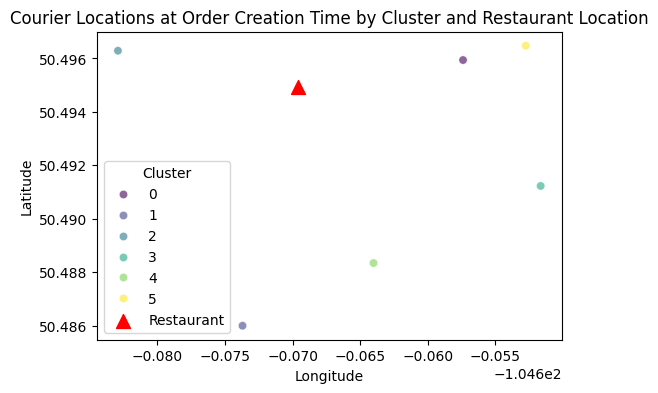

In [ ]:
# Plot courier locations from df_at_order_time, colored by cluster
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df_at_order_time, x='courier_lon', y='courier_lat', hue='cluster', palette='viridis', alpha=0.6) # Removed label='Couriers'

# Add restaurant location as a triangle
# Assuming there's only one restaurant location per order in df_at_order_time
restaurant_lat = df_at_order_time['restaurant_lat'].iloc[0]
restaurant_lon = df_at_order_time['restaurant_lon'].iloc[0]
plt.scatter(restaurant_lon, restaurant_lat, color='red', marker='^', s=100, label='Restaurant')


plt.title('Courier Locations at Order Creation Time by Cluster and Restaurant Location')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Cluster')
plt.show()

In [ ]:
# Step 2: Q-Learning for courier assignment
class QLearningAgent:
    def __init__(self, n_actions, learning_rate=0.1, discount_factor=0.9, epsilon=0.05):
        self.q_table = {}  # State-action value table
        self.lr = learning_rate
        self.gamma = discount_factor
        self.epsilon = epsilon
        self.n_actions = n_actions

    def get_state(self, order_number, cluster):
        return f"{order_number}_{cluster}"

    def choose_action(self, state, available_couriers):
        if random.uniform(0, 1) < self.epsilon:
            return random.choice(available_couriers)  # Explore
        else:
            q_values = {courier: self.q_table.get((state, courier), 0) for courier in available_couriers}
            return max(q_values, key=q_values.get)  # Exploit

    def update(self, state, action, reward, next_state):
        current_q = self.q_table.get((state, action), 0)
        next_max_q = max([self.q_table.get((next_state, a), 0) for a in range(self.n_actions)], default=0)
        self.q_table[(state, action)] = current_q + self.lr * (reward + self.gamma * next_max_q - current_q)

In [ ]:
def assign_couriers_and_calculate_cost(df, rate_per_km=0.20, top_k_clusters=6, top_m_couriers=6):
    agent = QLearningAgent(n_actions=len(df['courier_id'].unique()))
    total_cost = 0
    reassignments = 0

    for order_number in df['order_number'].unique():
        df_clustered, kmeans = cluster_couriers(df, order_number, n_clusters=6)
        restaurant_lat = df[df['order_number'] == order_number]['restaurant_lat'].iloc[0]
        restaurant_lon = df[df['order_number'] == order_number]['restaurant_lon'].iloc[0]

        # Check if kmeans is None or clustering failed
        if kmeans is None or len(df_clustered) == 0:
            closest_clusters = [0]  # Fallback to a single cluster
            available_couriers = df_clustered['courier_id'].tolist() if not df_clustered.empty else []
            cluster_centers = []
        else:
            cluster_centers = kmeans.cluster_centers_
            distances_to_restaurant = [
                haversine_distance(restaurant_lat, restaurant_lon, center[0], center[1])
                for center in cluster_centers
            ]
            top_k_clusters = min(top_k_clusters, len(cluster_centers))
            closest_clusters = np.argsort(distances_to_restaurant)[:top_k_clusters]
            available_couriers = df_clustered[df_clustered['cluster'].isin(closest_clusters)]['courier_id'].tolist()

        # Ensure there are available couriers before proceeding
        if not available_couriers:
            continue  # Skip this order if no couriers are available

        df_clustered = df_clustered.copy()  # Avoid warnings in this branch
        courier_distances = df_clustered[df_clustered['cluster'].isin(closest_clusters)].apply(
            lambda x: haversine_distance(x['courier_lat'], x['courier_lon'], restaurant_lat, restaurant_lon),
            axis=1
        )
        top_m_indices = courier_distances.nsmallest(top_m_couriers).index
        available_couriers = df_clustered.loc[top_m_indices, 'courier_id'].tolist()
        state = agent.get_state(order_number, closest_clusters[0] if len(cluster_centers) > 0 else 0)
        assigned_courier = agent.choose_action(state, available_couriers)
        courier_data = df_clustered[df_clustered['courier_id'] == assigned_courier].iloc[0]
        distance = haversine_distance(courier_data['courier_lat'], courier_data['courier_lon'],
                                      restaurant_lat, restaurant_lon)
        cluster_id = courier_data['cluster']

        cost = distance * rate_per_km
        total_cost += cost

        reward = -distance
        # Increment reassignments if order_assignment_unsuccess_binary == 1 for this order
        if df[df['order_number'] == order_number]['order_assignment_unsuccess_binary'].iloc[0] == 1:
            reward -= 10
            reassignments += 1

        next_state = agent.get_state(order_number, cluster_id if cluster_id != -1 else 0)
        agent.update(state if cluster_id != -1 else f"{order_number}_fallback", assigned_courier, reward, next_state)

    return total_cost, reassignments

In [ ]:
# Run the assignment and calculate profitability metrics
total_cost, reassignments = assign_couriers_and_calculate_cost(df_sorted_first, rate_per_km=0.20, top_k_clusters=6, top_m_couriers=10)
print(f"Total Delivery Cost: ${total_cost:.2f}")
print(f"Number of Reassignments: {reassignments}")

Total Delivery Cost: $255.57
Number of Reassignments: 533


In [ ]:
df_sorted_first.head()

,courier_id,order_number,courier_location_timestamp,courier_lat,courier_lon,order_created_timestamp,restaurant_lat,restaurant_lon,distance_km,cost,order_hour,courier_hour,number_of_unsucessful_assignment,courier_order_rank,order_assignment_unsuccess_binary
6582,67278c93hoho1c7ehoho41a7hohobb9bhohoae8ad6736840,280946408,2021-04-01 06:06:44.100000+00:00,50.497626,-104.642409,2021-04-01 06:00:08+00:00,50.496454,-104.638492,0.306192,0.061238,6,6,0,0.0,0
2872,e125dd35hoho254fhoho42c6hoho9060hoho546964984370,280946435,2021-04-01 06:10:02.325000+00:00,50.433371,-104.541239,2021-04-01 06:00:10+00:00,50.444124,-104.545164,1.227560,0.245512,6,6,0,0.0,0
6926,adbb9536hoho0f29hoho4b8chohobb16hoho2da5ec571e5e,280946558,2021-04-01 06:20:19.151000+00:00,50.433388,-104.631226,2021-04-01 06:00:22+00:00,50.444714,-104.617788,1.578483,0.315697,6,6,0,0.0,0
4717,1ea4602bhohoed79hoho4b74hohoa512hoho5d1087b5449c,280946645,2021-04-01 06:10:11.270000+00:00,50.447129,-104.600948,2021-04-01 06:00:31+00:00,50.449888,-104.606199,0.482044,0.096409,6,6,0,0.0,0
10263,a03c5da9hohod282hoho4daahohob881hoho653cd946c352,280946646,2021-04-01 06:09:58.245000+00:00,50.406716,-104.656555,2021-04-01 06:00:32+00:00,50.406109,-104.652070,0.324966,0.064993,6,6,0,0.0,0
